## Анализ заказов на точки лета 25-26 годов
Цель иследования попробовать оценить производительности лета 25 года с летом 26 года



In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_2025 = pd.read_csv('sales_2025_ready.csv')
df_2026 = pd.read_csv('sales_2026_ready.csv')

# 1. Загружаем сохраненные данные из других файлов
sales_2025 = pd.read_csv('sales_2025_ready.csv')
sales_2026 = pd.read_csv('sales_2026_ready.csv')

# 2. Склеиваем таблицы по имени товара и категории
df_compare = pd.merge(sales_2025, sales_2026, on=['Category', 'Name'], how='outer')

# 3. Заменяем пустоты (NaN) на нули
df_compare = df_compare.fillna(0)

# 4. Считаем абсолютную динамику (в штуках) и относительную (в процентах)
df_compare['Delta_Pcs'] = df_compare['Sales_2026'] - df_compare['Sales_2025']

df_compare['Delta_%'] = np.where(
    df_compare['Sales_2025'] > 0, 
    (df_compare['Delta_Pcs'] / df_compare['Sales_2025']) * 100, 
    100.0  # если товар новый, пишем 100% рост
)

print("Таблица сравнения годов успешно создана!")
df_compare.sort_values('Delta_Pcs', ascending=False).head(10)


Таблица сравнения годов успешно создана!


,Category,Name,Sales_2025,Sales_2026,Delta_Pcs,Delta_%
41,Выпечка,Морнинг бан жасмин,0.0,2300.0,2300.0,100.000000
51,Десерты,Паштель де ната,0.0,1767.0,1767.0,100.000000
15,Выпечка,Аманн,1937.0,3533.0,1596.0,82.395457
32,Выпечка,Кекс шоколад с кремом вареная сгущенка,0.0,1213.0,1213.0,100.000000
78,Печенье,Печенье для собак,0.0,1020.0,1020.0,100.000000
27,Выпечка,Кекс мак-лимон,18.0,996.0,978.0,5433.333333
74,ПФ Печенье,ПФ печенье шоколад-соль,0.0,975.0,975.0,100.000000
11,Булки,Кунжутная булка,0.0,948.0,948.0,100.000000
82,Печенье,Печенье шоколадное с солью,442.0,1277.0,835.0,188.914027
24,Выпечка,Даниш вишня,0.0,794.0,794.0,100.000000


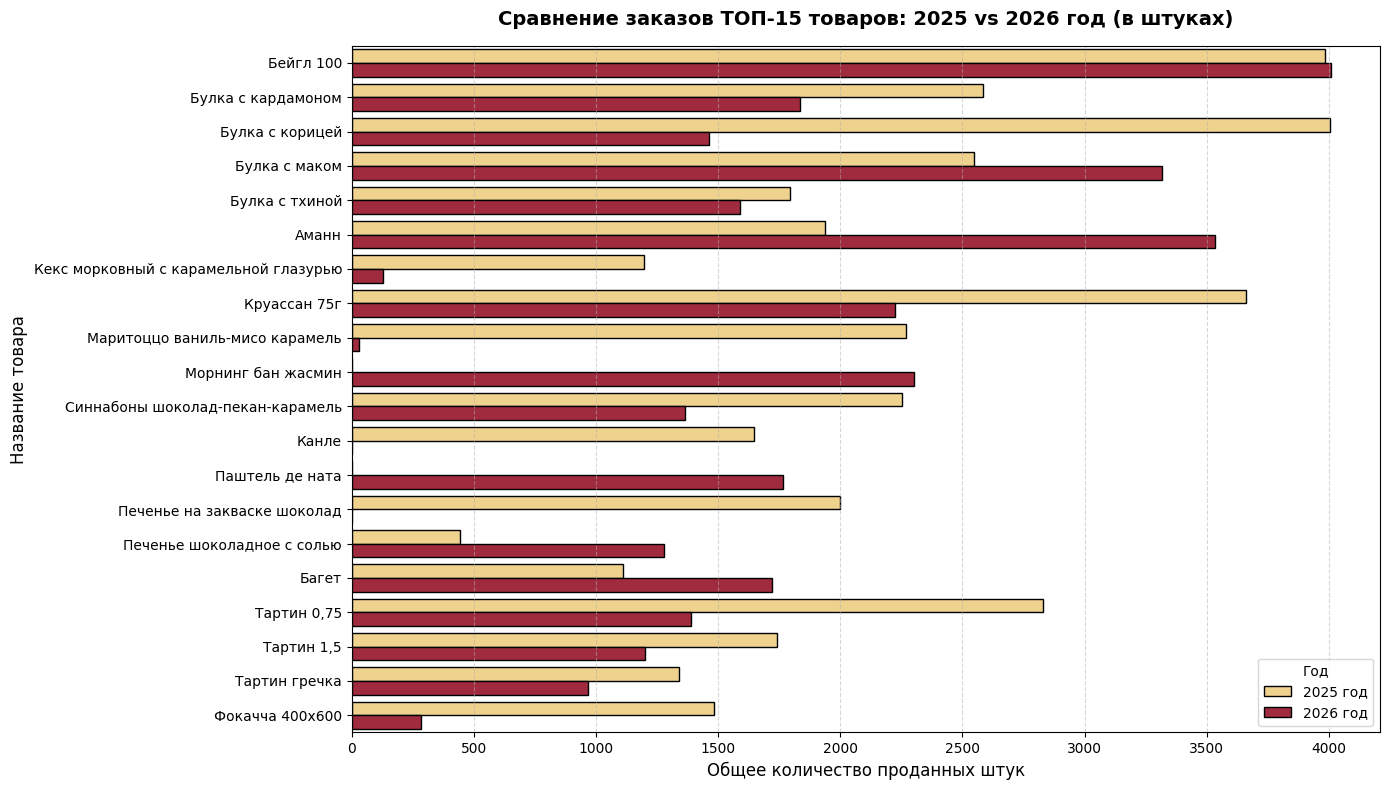

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Отбираем топ-10 товаров по суммарным заказовам за оба года, чтобы график был репрезентативным
df_compare['Total_Both_Years'] = df_compare['Sales_2025'] + df_compare['Sales_2026']
top_20_products = df_compare.sort_values('Total_Both_Years', ascending=False).head(20)['Name'].tolist()

# Фильтруем нашу таблицу сравнения, оставляя только эти топ-10 товаров
df_top20 = df_compare[df_compare['Name'].isin(top_20_products)]

# 2. Переводим данные из широкого формата в длинный, чтобы Seaborn смог построить раздельные столбики
df_plot = df_top20.melt(
    id_vars=['Name'], 
    value_vars=['Sales_2025', 'Sales_2026'], 
    var_name='Год', 
    value_name='заказови_шт'
)

# Красиво переименуем метки годов для легенды
df_plot['Год'] = df_plot['Год'].map({'Sales_2025': '2025 год', 'Sales_2026': '2026 год'})

# 3. Строим график
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_plot, 
    x='заказови_шт', 
    y='Name', 
    hue='Год', 
    palette=['#FFD97D', '#B51731'], # Желтый для 2025, Красный для 2026
    edgecolor='black'
)

# Оформление
plt.title('Сравнение заказов ТОП-15 товаров: 2025 vs 2026 год (в штуках)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Общее количество проданных штук', fontsize=12)
plt.ylabel('Название товара', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 1. Самое сильное падение Булки С Корицей
### 2. Амман стал заказываться ощутимо чаще
### 3. Почти весь хлеб стал заказываться реже


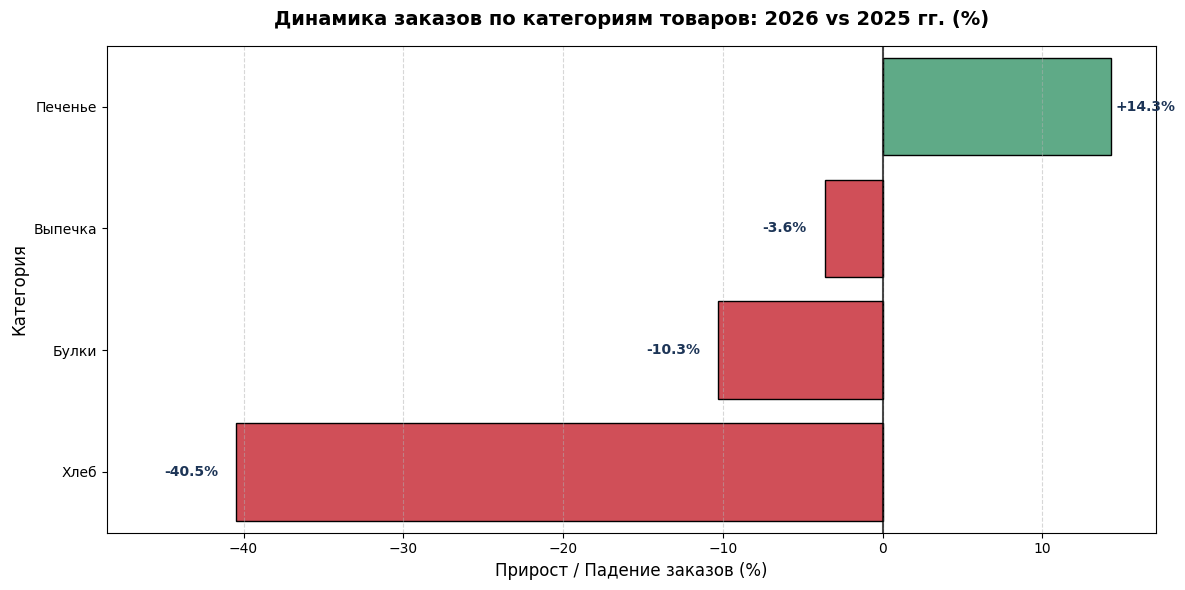

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Группируем данные по категориям и считаем сумму заказов за два года
cat_compare = (
    df_compare.groupby("Category")[["Sales_2025", "Sales_2026"]].sum().reset_index()
)

# Исправленная фильтрация: оставляем только нужные 4 категории мучных изделий
bakery_categories = ["Печенье", "Булки", "Выпечка", "Хлеб"]
cat_compare = cat_compare[cat_compare["Category"].isin(bakery_categories)]

# 2. Считаем процентный прирост (динамику) год к году
cat_compare["Growth_%"] = (
    (cat_compare["Sales_2026"] - cat_compare["Sales_2025"]) / cat_compare["Sales_2025"]
) * 100

# Отсортируем категории от самых растущих к самым падающим
cat_compare = cat_compare.sort_values("Growth_%", ascending=False)

# ==========================================
# 3. СТРОИМ ГРАФИК ДИНАМИКИ КАТЕГОРИЙ
# ==========================================
plt.figure(figsize=(12, 6))

# Задаем цвета динамически: зеленый для роста (>0), красный для падения (<0)
colors = ["#52B788" if x >= 0 else "#E63946" for x in cat_compare["Growth_%"]]

# Принудительно передаем список цветов в hue, чтобы Seaborn не ругался на палитру
sns.barplot(
    data=cat_compare,
    x="Growth_%",
    y="Category",
    hue="Category",
    palette=dict(zip(cat_compare["Category"], colors)),
    legend=False,
    edgecolor="black",
)

# Оформление графика
plt.title(
    "Динамика заказов по категориям товаров: 2026 vs 2025 гг. (%)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Прирост / Падение заказов (%)", fontsize=12)
plt.ylabel("Категория", fontsize=12)

# Настройка границ оси X с запасом, чтобы цифры не вылезали за края
max_val = cat_compare["Growth_%"].max()
min_val = cat_compare["Growth_%"].min()
plt.xlim(min_val * 1.2 if min_val < 0 else -10, max_val * 1.2 if max_val > 0 else 10)

# Добавляем вертикальную линию на уровне 0 для наглядности
plt.axvline(0, color="black", linestyle="-", linewidth=1.5, alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Дописываем точные значения процентов прямо на барах
for i, val in enumerate(cat_compare["Growth_%"]):
    plus_sign = "+" if val > 0 else ""
    # Сдвиг текста зависит от того, положительное число или отрицательное
    offset = max_val * 0.02 if val >= 0 else -max_val * 0.08
    align = "left" if val >= 0 else "right"

    plt.text(
        val + offset,
        i,
        f"{plus_sign}{val:.1f}%",
        va="center",
        ha=align,
        fontsize=10,
        weight="bold",
        color="#1D3557",
    )

plt.tight_layout()
plt.show()

In [5]:
sales_2025[sales_2025['Category'] == 'Выпечка']['Sales_2025'].sum()

np.float64(15798.0)

In [6]:
sales_2026[sales_2026['Category'] == 'Выпечка']['Sales_2026'].sum()

np.float64(15226.0)

# Выпечка за 2026 год

In [7]:
sales_2026[sales_2026['Category'] == 'Выпечка'].sort_values(by='Sales_2026', ascending=False)

,Category,Name,Sales_2026
8,Выпечка,Аманн,3533.0
23,Выпечка,Морнинг бан жасмин,2300.0
20,Выпечка,Круассан 75г,2224.0
25,Выпечка,Синнабоны шоколад-пекан-карамель,1364.0
19,Выпечка,Кекс шоколад с кремом вареная сгущенка,1213.0
16,Выпечка,Кекс мак-лимон,996.0
13,Выпечка,Даниш вишня,794.0
14,Выпечка,Даниш франжипан грецкий орех,516.0
28,Выпечка,Хани баттер тост,496.0
26,Выпечка,Улитка заварной крем и изюм,493.0


# Выпечка за 2025 год

In [8]:
sales_2025[sales_2025['Category'] == 'Выпечка'].sort_values(by='Sales_2025', ascending=False)

,Category,Name,Sales_2025
30,Выпечка,Круассан 75г,3660.0
32,Выпечка,Маритоццо ваниль-мисо карамель,2267.0
35,Выпечка,Синнабоны шоколад-пекан-карамель,2253.0
12,Выпечка,Аманн,1937.0
24,Выпечка,Кекс морковный с карамельной глазурью,1195.0
23,Выпечка,Кекс мак-лимон с кремом,1182.0
17,Выпечка,Бабка корица и карамель,595.0
11,Выпечка,Morning bun цедра - кардамон,523.0
9,Выпечка,Honey butter toast,522.0
34,Выпечка,Синнабон с какао,442.0


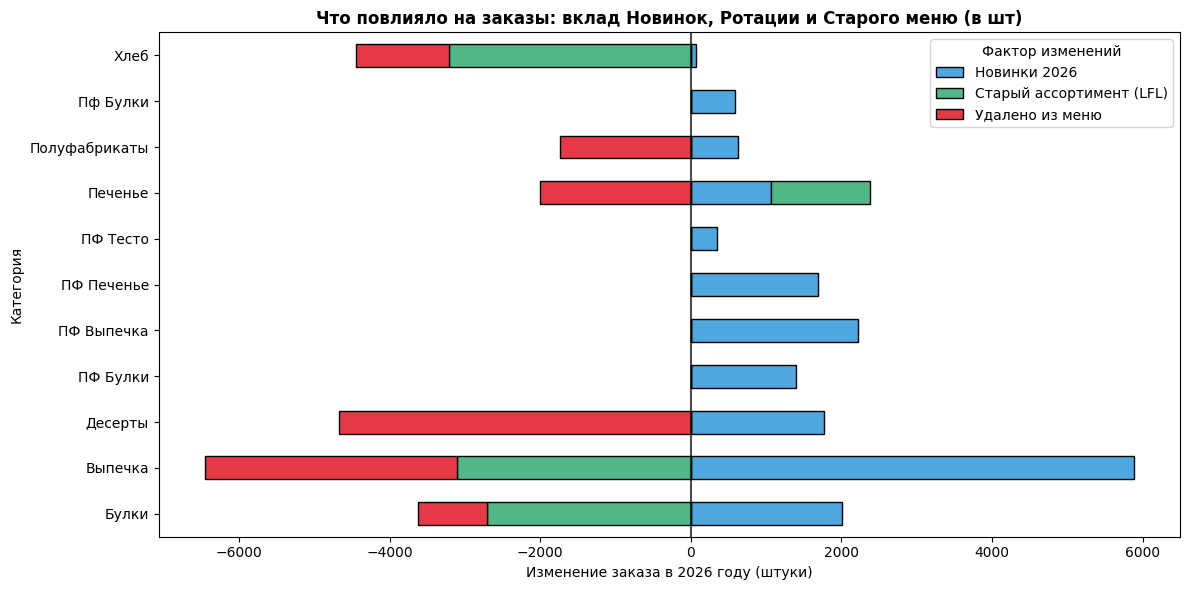

In [9]:
# Маркируем тип товара
def get_product_type(row):
    if row['Sales_2025'] == 0 and row['Sales_2026'] > 0: return 'Новинки 2026'
    if row['Sales_2025'] > 0 and row['Sales_2026'] == 0: return 'Удалено из меню'
    return 'Старый ассортимент (LFL)'

df_compare['Product_Type'] = df_compare.apply(get_product_type, axis=1)

# Считаем вклад в штуках (разницу)
df_compare['Delta_Pcs'] = df_compare['Sales_2026'] - df_compare['Sales_2025']

# Группируем категорию и тип товара
contribution = df_compare.groupby(['Category', 'Product_Type'])['Delta_Pcs'].sum().unstack().fillna(0)

# Строим Stacked Bar Chart
contribution.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#4EA8DE', '#52B788', '#E63946'], edgecolor='black')
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
plt.title('Что повлияло на заказы: вклад Новинок, Ротации и Старого меню (в шт)', fontsize=12, weight='bold')
plt.xlabel('Изменение заказа в 2026 году (штуки)')
plt.ylabel('Категория')
plt.legend(title="Фактор изменений")
plt.tight_layout()
plt.show()


### Новинки компенсируют ротацию в полуфабрикатах, но не в десертах
 Самый сильный ввод новых позиций зафиксирован в «Выпечке» (+5 900 шт.) и группе полуфабрикатов (ПФ Выпечка, ПФ Печенье, ПФ Булки дали суммарно около +6 000 шт.). Однако в «Десертах» удаление позиций (-4 700 шт.) сильно превысило объем заказов новинок (+1 750 шт.).

### Органическое падение LFL-ассортимента
 В базовых категориях «Хлеб», «Выпечка» и «Булки» наблюдается существенная усадка старого меню (-3 200, -3 100 и -2 700 шт. соответственно). Покупатели сокращают потребление прежних классических позиций.

### Печенье показывает лучший LFL-рост
 Печенье — единственная категория, где сохраненные позиции старого ассортимента выросли (+1 350 шт.), что позволило категории суммарно выйти в плюс (+400 шт.), несмотря на вывод части ассортимента.

### Структурный сдвиг в сторону ПФ
 Категории полуфабрикатов (ПФ) показывают чистый прирост исключительно за счет новинок, что компенсирует часть общих потерь готовой выпечки и булок.

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_5976\896204053.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lfl_cat, x='LFL_Growth_%', y='Category', palette=colors, edgecolor='black')


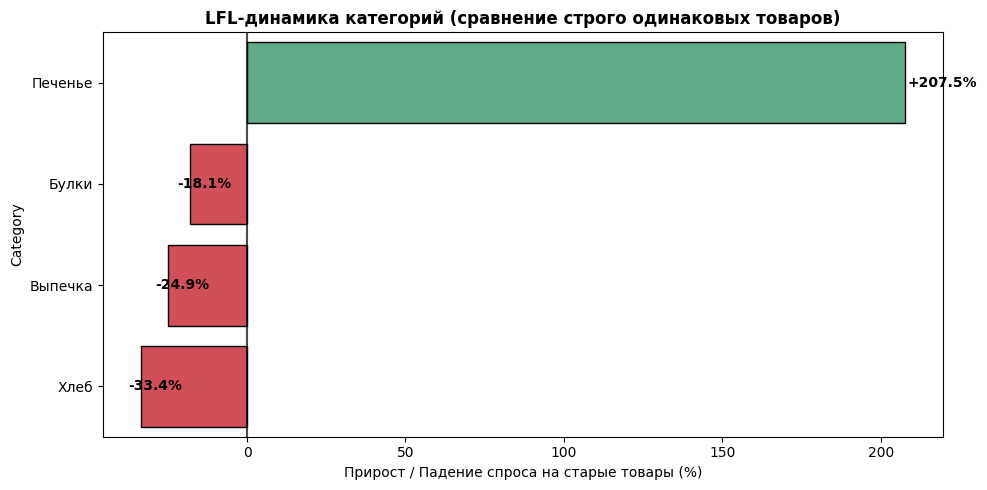

In [10]:
# Оставляем только товары, у которых заказови БОЛЬШЕ НУЛЯ в обоих годах
df_lfl = df_compare[(df_compare['Sales_2025'] > 0) & (df_compare['Sales_2026'] > 0)].copy()

# Считаем динамику LFL по категориям
lfl_cat = df_lfl.groupby('Category')[['Sales_2025', 'Sales_2026']].sum().reset_index()
lfl_cat['LFL_Growth_%'] = ((lfl_cat['Sales_2026'] - lfl_cat['Sales_2025']) / lfl_cat['Sales_2025']) * 100
lfl_cat = lfl_cat.sort_values('LFL_Growth_%', ascending=False)

# Строим график
plt.figure(figsize=(10, 5))
colors = ['#52B788' if x >= 0 else '#E63946' for x in lfl_cat['LFL_Growth_%']]
sns.barplot(data=lfl_cat, x='LFL_Growth_%', y='Category', palette=colors, edgecolor='black')
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
plt.title('LFL-динамика категорий (сравнение строго одинаковых товаров)', fontsize=12, weight='bold')
plt.xlabel('Прирост / Падение спроса на старые товары (%)')

for i, val in enumerate(lfl_cat['LFL_Growth_%']):
    plt.text(val + (1 if val >= 0 else -4), i, f"{'+' if val > 0 else ''}{val:.1f}%", va='center', weight='bold')
plt.tight_layout()
plt.show()


In [11]:
# 1. Берем только категорию Выпечка из нашей LFL-таблицы
vypechka_lfl = df_lfl[df_lfl['Category'] == 'Выпечка'].copy()

# 2. Считаем чистый прирост в штуках для каждого товара
vypechka_lfl['Pcs_Gain'] = vypechka_lfl['Sales_2026'] - vypechka_lfl['Sales_2025']

print("--- ИЩЕМ АНОМАЛИЮ В ВЫПЕЧКЕ ---")
# Выводим товары, отсортировав от самых подозрительных
print(vypechka_lfl[['Name', 'Sales_2025', 'Sales_2026', 'Pcs_Gain']].sort_values('Pcs_Gain', ascending=False).to_string(index=False))


--- ИЩЕМ АНОМАЛИЮ В ВЫПЕЧКЕ ---
                                  Name  Sales_2025  Sales_2026  Pcs_Gain
                                 Аманн      1937.0      3533.0    1596.0
                        Кекс мак-лимон        18.0       996.0     978.0
Даниш яблочный пирог с заварным кремом        20.0       184.0     164.0
           Улитка заварной крем и изюм       417.0       493.0      76.0
                          Бабка Корица        37.0        88.0      51.0
                        Бабка Кардамон        54.0         1.0     -53.0
               Бабка корица и карамель       595.0       307.0    -288.0
      Синнабоны шоколад-пекан-карамель      2253.0      1364.0    -889.0
 Кекс морковный с карамельной глазурью      1195.0       126.0   -1069.0
                          Круассан 75г      3660.0      2224.0   -1436.0
        Маритоццо ваниль-мисо карамель      2267.0        30.0   -2237.0


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_5976\2402856652.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lfl_cat, x='LFL_Gain_Pcs', y='Category', palette=colors, edgecolor='black')


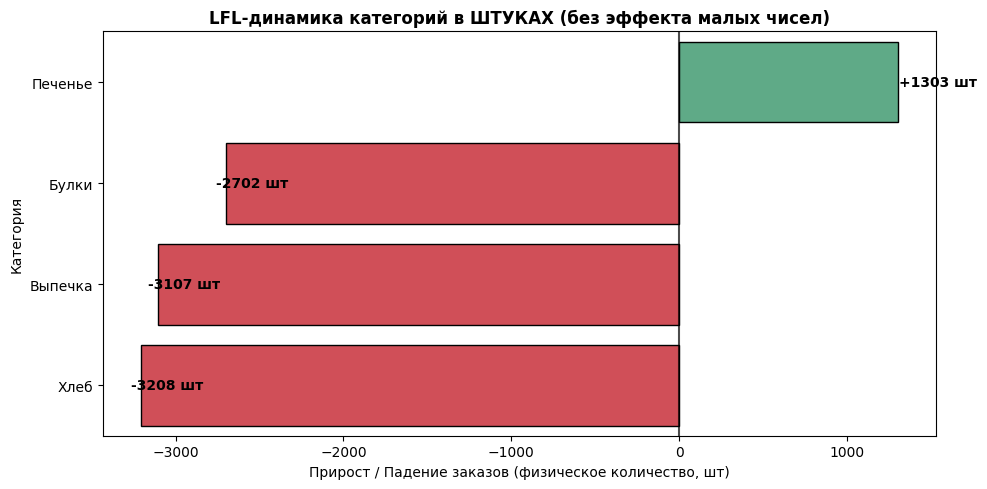

In [12]:
# Строим LFL-динамику категорий строго в ШТУКАХ
plt.figure(figsize=(10, 5))

# Считаем разницу в штуках для каждой категории
lfl_cat['LFL_Gain_Pcs'] = lfl_cat['Sales_2026'] - lfl_cat['Sales_2025']
lfl_cat = lfl_cat.sort_values('LFL_Gain_Pcs', ascending=False)

# Задаем цвета: зеленый для роста, красный для падения
colors = ['#52B788' if x >= 0 else '#E63946' for x in lfl_cat['LFL_Gain_Pcs']]

sns.barplot(data=lfl_cat, x='LFL_Gain_Pcs', y='Category', palette=colors, edgecolor='black')
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

plt.title('LFL-динамика категорий в ШТУКАХ (без эффекта малых чисел)', fontsize=12, weight='bold')
plt.xlabel('Прирост / Падение заказов (физическое количество, шт)')
plt.ylabel('Категория')

# Подписываем точные штуки на столбиках
for i, val in enumerate(lfl_cat['LFL_Gain_Pcs']):
    plus_sign = "+" if val > 0 else ""
    plt.text(val + (10 if val >= 0 else -60), i, f"{plus_sign}{val:.0f} шт", va='center', weight='bold')

plt.tight_layout()
plt.show()


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_5976\2365147169.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bulki, x='Gain_Pcs', y='Name', palette=colors, edgecolor='black')


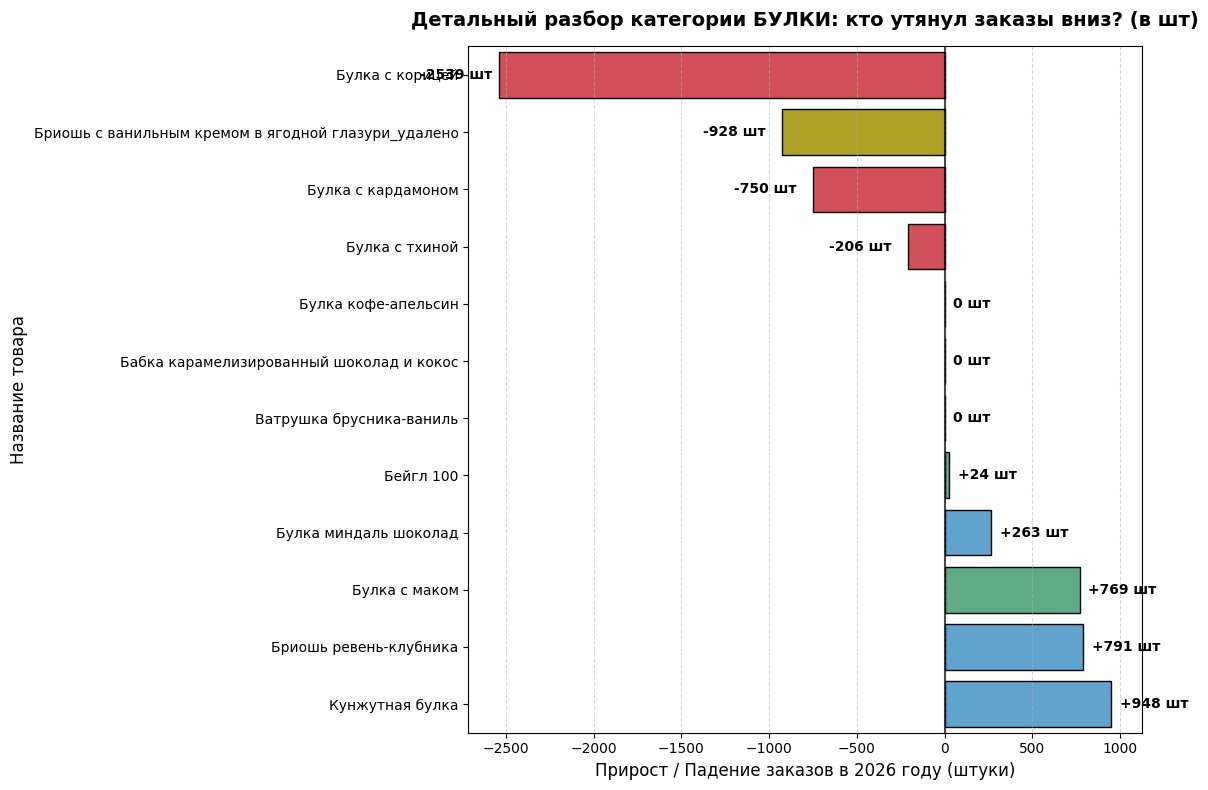

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Отфильтровываем только категорию "Булки"
bulki = df_compare[df_compare['Category'] == 'Булки'].copy()

# 2. Считаем чистый прирост/падение в штуках
bulki['Gain_Pcs'] = bulki['Sales_2026'] - bulki['Sales_2025']

# Сортируем от самых просевших к растущим
bulki = bulki.sort_values('Gain_Pcs', ascending=True)

# 3. Строим горизонтальный график по каждому товару
plt.figure(figsize=(12, 8))

# Зеленый для роста, красный для падения, синий для абсолютных новинок
colors = []
for idx, row in bulki.iterrows():
    if row['Sales_2025'] == 0:
        colors.append('#4EA8DE') # Синий — новинка 2026
    elif row['Delta_%'] == -100.0:
        colors.append("#C4B210")
    elif row['Gain_Pcs'] >= 0:
        colors.append('#52B788') # Зеленый — вырос
    else:
        colors.append('#E63946') # Красный — упал
bulki.loc[bulki['Delta_%'] == -100.0, 'Name'] = bulki['Name'] + "_удалено"
sns.barplot(data=bulki, x='Gain_Pcs', y='Name', palette=colors, edgecolor='black')
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

plt.title('Детальный разбор категории БУЛКИ: кто утянул заказы вниз? (в шт)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Прирост / Падение заказов в 2026 году (штуки)', fontsize=12)
plt.ylabel('Название товара', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Добавляем текстовые подписи штук прямо на график
for i, row in enumerate(bulki.itertuples()):
    val = row.Gain_Pcs
    plus_sign = "+" if val > 0 else ""
    # Сдвигаем текст в зависимости от знака
    offset = 50 if val >= 0 else -450
    plt.text(val + offset, i, f"{plus_sign}{val:.0f} шт", va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_5976\2510434143.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vipechka , x='Gain_Pcs', y='Name', palette=colors, edgecolor='black')


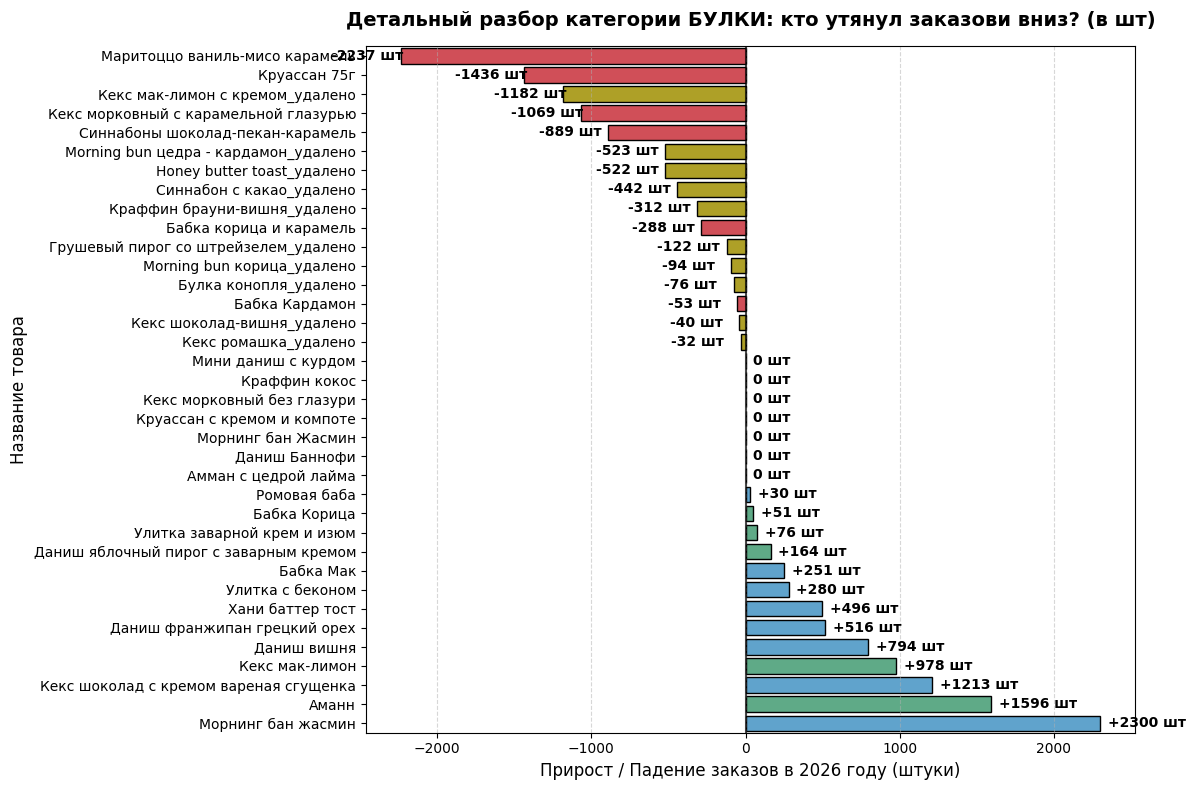

In [ ]:

vipechka = df_compare[df_compare['Category'] == 'Выпечка'].copy()

# 2. Считаем чистый прирост/падение в штуках
vipechka ['Gain_Pcs'] = vipechka ['Sales_2026'] - vipechka ['Sales_2025']

# Сортируем от самых просевших к растущим
vipechka  = vipechka .sort_values('Gain_Pcs', ascending=True)

# 3. Строим горизонтальный график по каждому товару
plt.figure(figsize=(12, 8))

# Зеленый для роста, красный для падения, синий для абсолютных новинок
colors = []
for idx, row in vipechka .iterrows():
    if row['Sales_2025'] == 0:
        colors.append('#4EA8DE') # Синий — новинка 2026
    elif row['Delta_%'] == -100.0:
        colors.append("#C4B210")
    elif row['Gain_Pcs'] >= 0:
        colors.append('#52B788') # Зеленый — вырос
    else:
        colors.append('#E63946') # Красный — упал
vipechka .loc[vipechka ['Delta_%'] == -100.0, 'Name'] = vipechka ['Name'] + "_удалено"
sns.barplot(data=vipechka , x='Gain_Pcs', y='Name', palette=colors, edgecolor='black')
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

plt.title('Детальный разбор категории БУЛКИ: кто утянул заказы вниз? (в шт)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Прирост / Падение заказов в 2026 году (штуки)', fontsize=12)
plt.ylabel('Название товара', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Добавляем текстовые подписи штук прямо на график
for i, row in enumerate(vipechka .itertuples()):
    val = row.Gain_Pcs
    plus_sign = "+" if val > 0 else ""
    # Сдвигаем текст в зависимости от знака
    offset = 50 if val >= 0 else -450
    plt.text(val + offset, i, f"{plus_sign}{val:.0f} шт", va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()


### Маритоццо ваниль-мисо шоколад почти была удалена
 В 26 году эту позицию заказывали очень мало и только в начале лета
### Круасан 75г стали намного меньше заказывать
 

In [15]:
names_that_not_deleted = df_compare[
    df_compare['Delta_%'] == -100.0
]['Name'].to_list()

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_5976\238670029.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=deserty, x='Gain_Pcs', y='Name', palette=colors, edgecolor='black')


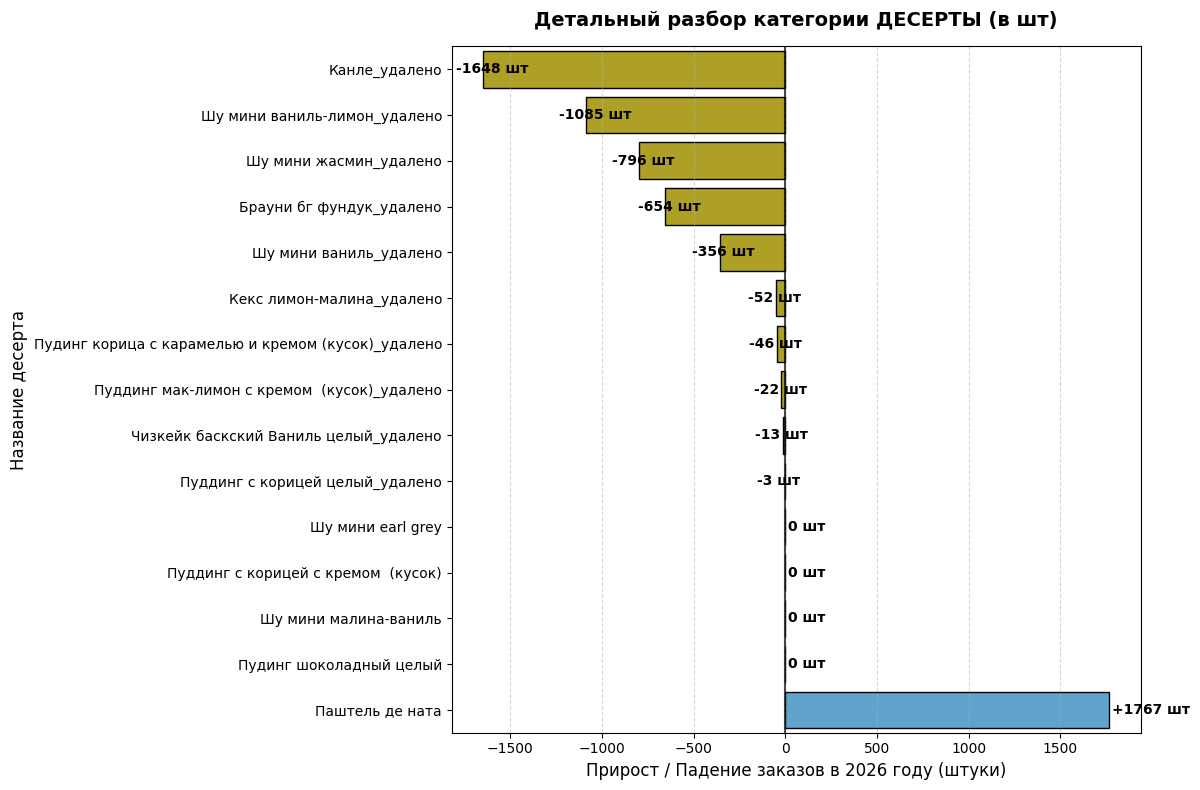

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Отфильтровываем только категорию "Десерты"
deserty = df_compare[df_compare['Category'] == 'Десерты'].copy()

# 2. Считаем чистый прирост/падение в штуках
deserty['Gain_Pcs'] = deserty['Sales_2026'] - deserty['Sales_2025']

# Сортируем от самых просевших к самым растущим
deserty = deserty.sort_values('Gain_Pcs', ascending=True)

# 3. Строим горизонтальный график
plt.figure(figsize=(12, 8))

# Задаем цвета: синий для новинок 2026, зеленый для роста старых, красный для падения
colors = []
for idx, row in deserty.iterrows():
    if row['Sales_2025'] == 0:
        colors.append('#4EA8DE') # Синий — новинка 2026
    elif row['Delta_%'] == -100.0:
        colors.append("#C4B210")
    elif row['Gain_Pcs'] >= 0:
        colors.append('#52B788') # Зеленый — вырос (LFL)
    else:
        colors.append('#E63946') # Красный — упал (LFL)
deserty.loc[deserty['Delta_%'] == -100.0, 'Name'] = deserty['Name'] + "_удалено"
sns.barplot(data=deserty, x='Gain_Pcs', y='Name', palette=colors, edgecolor='black')
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

plt.title('Детальный разбор категории ДЕСЕРТЫ (в шт)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Прирост / Падение заказов в 2026 году (штуки)', fontsize=12)
plt.ylabel('Название десерта', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Добавляем текстовые подписи штук прямо на график
for i, row in enumerate(deserty.itertuples()):
    val = row.Gain_Pcs
    plus_sign = "+" if val > 0 else ""
    # Подстраиваем отступ текста, чтобы всё помещалось
    offset = 15 if val >= 0 else -150
    plt.text(val + offset, i, f"{plus_sign}{val:.0f} шт", va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()


In [17]:
deserty

,Category,Name,Sales_2025,Sales_2026,Delta_Pcs,Delta_%,Total_Both_Years,Product_Type,Gain_Pcs
49,Десерты,Канле_удалено,1648.0,0.0,-1648.0,-100.0,1648.0,Удалено из меню,-1648.0
60,Десерты,Шу мини ваниль-лимон_удалено,1085.0,0.0,-1085.0,-100.0,1085.0,Удалено из меню,-1085.0
61,Десерты,Шу мини жасмин_удалено,796.0,0.0,-796.0,-100.0,796.0,Удалено из меню,-796.0
48,Десерты,Брауни бг фундук_удалено,654.0,0.0,-654.0,-100.0,654.0,Удалено из меню,-654.0
59,Десерты,Шу мини ваниль_удалено,356.0,0.0,-356.0,-100.0,356.0,Удалено из меню,-356.0
50,Десерты,Кекс лимон-малина_удалено,52.0,0.0,-52.0,-100.0,52.0,Удалено из меню,-52.0
55,Десерты,Пудинг корица с карамелью и кремом (кусок)_уда...,46.0,0.0,-46.0,-100.0,46.0,Удалено из меню,-46.0
52,Десерты,Пуддинг мак-лимон с кремом (кусок)_удалено,22.0,0.0,-22.0,-100.0,22.0,Удалено из меню,-22.0
57,Десерты,Чизкейк баскский Ваниль целый_удалено,13.0,0.0,-13.0,-100.0,13.0,Удалено из меню,-13.0
54,Десерты,Пуддинг с корицей целый_удалено,3.0,0.0,-3.0,-100.0,3.0,Удалено из меню,-3.0


In [18]:
# Изменяем только те строки, где Delta_% равен -100.0
deserty.loc[deserty['Delta_%'] == -100.0, 'Name'] = deserty['Name'] + "_удалено"
deserty

,Category,Name,Sales_2025,Sales_2026,Delta_Pcs,Delta_%,Total_Both_Years,Product_Type,Gain_Pcs
49,Десерты,Канле_удалено_удалено,1648.0,0.0,-1648.0,-100.0,1648.0,Удалено из меню,-1648.0
60,Десерты,Шу мини ваниль-лимон_удалено_удалено,1085.0,0.0,-1085.0,-100.0,1085.0,Удалено из меню,-1085.0
61,Десерты,Шу мини жасмин_удалено_удалено,796.0,0.0,-796.0,-100.0,796.0,Удалено из меню,-796.0
48,Десерты,Брауни бг фундук_удалено_удалено,654.0,0.0,-654.0,-100.0,654.0,Удалено из меню,-654.0
59,Десерты,Шу мини ваниль_удалено_удалено,356.0,0.0,-356.0,-100.0,356.0,Удалено из меню,-356.0
50,Десерты,Кекс лимон-малина_удалено_удалено,52.0,0.0,-52.0,-100.0,52.0,Удалено из меню,-52.0
55,Десерты,Пудинг корица с карамелью и кремом (кусок)_уда...,46.0,0.0,-46.0,-100.0,46.0,Удалено из меню,-46.0
52,Десерты,Пуддинг мак-лимон с кремом (кусок)_удалено_уд...,22.0,0.0,-22.0,-100.0,22.0,Удалено из меню,-22.0
57,Десерты,Чизкейк баскский Ваниль целый_удалено_удалено,13.0,0.0,-13.0,-100.0,13.0,Удалено из меню,-13.0
54,Десерты,Пуддинг с корицей целый_удалено_удалено,3.0,0.0,-3.0,-100.0,3.0,Удалено из меню,-3.0


In [19]:
sales_2026['Name'].unique().tolist()

['Бейгл 100',
 'Бриошь ревень-клубника',
 'Булка миндаль шоколад',
 'Булка с кардамоном',
 'Булка с корицей',
 'Булка с маком',
 'Булка с тхиной',
 'Кунжутная булка',
 'Аманн',
 'Бабка Кардамон',
 'Бабка Корица',
 'Бабка Мак',
 'Бабка корица и карамель',
 'Даниш вишня',
 'Даниш франжипан грецкий орех',
 'Даниш яблочный пирог с заварным кремом',
 'Кекс мак-лимон',
 'Кекс морковный без глазури',
 'Кекс морковный с карамельной глазурью',
 'Кекс шоколад с кремом вареная сгущенка',
 'Круассан 75г',
 'Маритоццо ваниль-мисо карамель',
 'Морнинг бан Жасмин',
 'Морнинг бан жасмин',
 'Ромовая баба',
 'Синнабоны шоколад-пекан-карамель',
 'Улитка заварной крем и изюм',
 'Улитка с беконом',
 'Хани баттер тост',
 'Паштель де ната',
 'ПФ Булка корица',
 'ПФ Булка тхина',
 'ПФ бейгл 100',
 'Пф Булка миндаль шоколад',
 'ПФ Аманн',
 'ПФ Даниш',
 'ПФ Даниш отпечённый',
 'ПФ Даниш отпечённый с курдом',
 'ПФ Морнинг бан жасмин',
 'ПФ синнабон',
 'ПФ печенье финик-пекан',
 'ПФ печенье шоколад-соль',
 'Пф Фи

In [20]:
df_2025 = pd.read_csv('raw_2025.csv')
df_2026 = pd.read_csv('raw_2026.csv')
# Словарь для коротких дней и строгий порядок
# short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# # 1. Строим сводную таблицу средних заказов для 2025 года
# df_2025['Day_Short'] = df_2025['Date'].dt.day_name().map(short_days)
pivot_2025 = df_2025.pivot_table(index='Day_of_week', columns='Point', values='Count', aggfunc='mean').reindex(day_order)

# # 2. Строим точно такую же сводную таблицу для 2026 года
# df_2026['Day_Short'] = df_2026['Date'].dt.day_name().map(short_days)
pivot_2026 = df_2026.pivot_table(index='Day_of_week', columns='Point', values='Count', aggfunc='mean').reindex(day_order)

# Находим общие точки, которые работали в оба года, чтобы сравнение было честным
common_points = list(set(pivot_2025.columns) & set(pivot_2026.columns))

# 3. Вычитаем 2025 год из 2026 года по общим точкам
diff_pivot = pivot_2026[common_points] - pivot_2025[common_points]

print("Матрица изменений поведения клиентов готова!")



Матрица изменений поведения клиентов готова!


In [21]:
# plt.figure(figsize=(16, 8))

# # Находим максимальное абсолютное отклонение, чтобы центрировать шкалу на 0
# vmax = np.max(np.abs(diff_pivot.fillna(0).values))

# # Строим хитмап. center=0 — это критически важно для разностных карт
# sns.heatmap(
#     diff_pivot, 
#     annot=True, 
#     fmt=".1f", 
#     cmap='RdBu_r', 
#     center=0, 
#     vmax=vmax, 
#     vmin=-vmax, 
#     linewidths=0.5
# )

# plt.title('Разностная карта спроса (2026 минус 2025): Как изменилось поведение клиентов', fontsize=14, pad=15, weight='bold')
# plt.ylabel('День недели', fontsize=12)
# plt.xlabel('Торговая точка', fontsize=12)
# plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()


In [22]:
# import numpy as np
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt

# # 1. Делаем копии, чтобы не испортить исходные данные
# df_25_clean = df_2025.copy()
# df_26_clean = df_2026.copy()

# # 2. Очищаем названия точек: стираем хвосты _2025, _2026, _25, _26
# for df in [df_25_clean, df_26_clean]:
#     df['Point'] = df['Point'].astype(str).str.replace('_2025', '', case=False)
#     df['Point'] = df['Point'].astype(str).str.replace('_2026', '', case=False)
#     df['Point'] = df['Point'].astype(str).str.replace('_25', '', case=False)
#     df['Point'] = df['Point'].astype(str).str.replace('_26', '', case=False)
#     df['Point'] = df['Point'].str.strip().str.upper() # убираем пробелы и делаем крупный шрифт

# # 3. Перестраиваем сводные таблицы с чистыми именами
# short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
# day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# df_25_clean['Day_Short'] = df_25_clean['Date'].dt.day_name().map(short_days)
# pivot_2025 = df_25_clean.pivot_table(index='Day_Short', columns='Point', values='Count', aggfunc='mean').reindex(day_order)

# df_26_clean['Day_Short'] = df_26_clean['Date'].dt.day_name().map(short_days)
# pivot_2026 = df_26_clean.pivot_table(index='Day_Short', columns='Point', values='Count', aggfunc='mean').reindex(day_order)

# # 4. Считаем ЧИСТУЮ РАЗНИЦУ по одинаковым точкам
# diff_pivot = pivot_2026.fillna(0) - pivot_2025.fillna(0)

# # Оставляем только те точки, которые реально существовали в оба года (чтобы убрать пустые столбики новичков)
# common_cols = list(set(pivot_2025.dropna(how='all', axis=1).columns) & set(pivot_2026.dropna(how='all', axis=1).columns))
# diff_pivot = diff_pivot[common_cols]

# # 5. СТРОИМ ГРАФИК
# plt.figure(figsize=(14, 7))
# sns.heatmap(
#     diff_pivot, 
#     annot=True, 
#     fmt=".1f", 
#     cmap='RdBu_r', 
#     center=0, 
#     linewidths=0.5
# )

# plt.title('Разностная карта спроса (2026 минус 2025): Как изменились средние заказови по дням', fontsize=14, pad=15, weight='bold')
# plt.ylabel('День недели', fontsize=12)
# plt.xlabel('Торговая точка', fontsize=12)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()



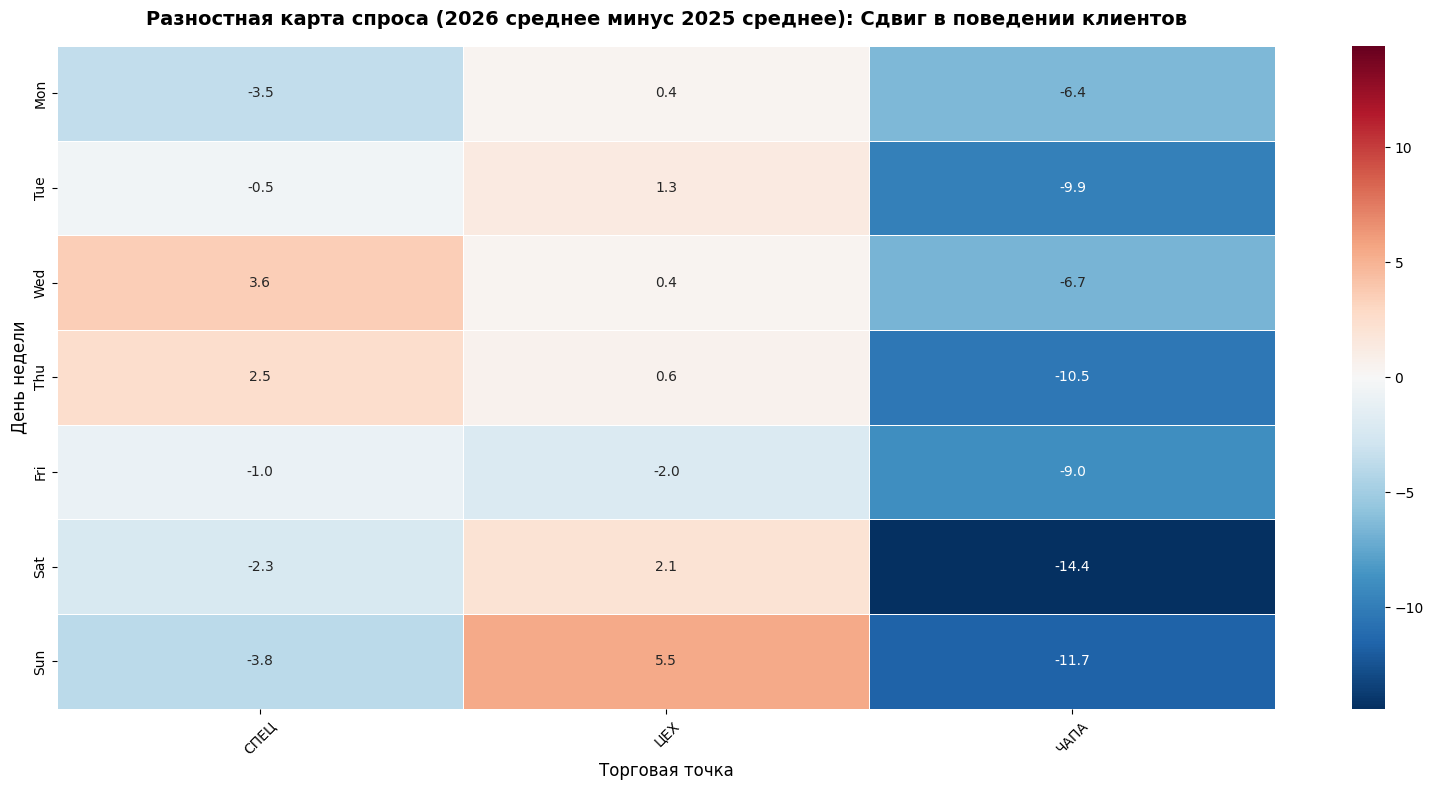

In [23]:
df_2025 = pd.read_csv('raw_2025.csv')
df_2026 = pd.read_csv('raw_2026.csv')

# Принудительно переводим даты в формат datetime, чтобы вытащить день недели
df_2025['Date'] = pd.to_datetime(df_2025['Date'], errors='coerce')
df_2026['Date'] = pd.to_datetime(df_2026['Date'], errors='coerce')

# 2. Очищаем названия точек от приписок годов (_2025, _2026, _25, _26)
for df in [df_2025, df_2026]:
    df['Point'] = df['Point'].astype(str).str.replace('_2025', '', case=False)
    df['Point'] = df['Point'].astype(str).str.replace('_2026', '', case=False)
    df['Point'] = df['Point'].astype(str).str.replace('_25', '', case=False)
    df['Point'] = df['Point'].astype(str).str.replace('_26', '', case=False)
    df['Point'] = df['Point'].str.strip().str.upper()

# 3. Добавляем короткие дни недели и задаем им строгий порядок от Пн до Вс
short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

df_2025['Day_Short'] = df_2025['Date'].dt.day_name().map(short_days)
df_2026['Day_Short'] = df_2026['Date'].dt.day_name().map(short_days)

# 4. АГРЕГИРУЕМ: Считаем средние заказови для каждого дня недели на каждой точке внутри своего года
pivot_2025 = df_2025.pivot_table(index='Day_Short', columns='Point', values='Count', aggfunc='mean').reindex(day_order)
pivot_2026 = df_2026.pivot_table(index='Day_Short', columns='Point', values='Count', aggfunc='mean').reindex(day_order)

# Находим только те точки, которые работали В ОБА ГОДА (чтобы убрать пустые столбики закрытых/новых точек)
common_points = list(set(pivot_2025.dropna(how='all', axis=1).columns) & set(pivot_2026.dropna(how='all', axis=1).columns))

# 5. СЧИТАЕМ РАЗНИЦУ: Вычитаем средние заказови 2025 года из 2026 года
diff_pivot = pivot_2026[common_points].fillna(0) - pivot_2025[common_points].fillna(0)

# 6. СТРОИМ РАЗНОСТНЫЙ ХИТМАП
plt.figure(figsize=(16, 8))

# Центрируем шкалу на 0, чтобы синий был минусом, а красный — плюсом
vmax = np.max(np.abs(diff_pivot.values)) if diff_pivot.size > 0 else 1

sns.heatmap(
    diff_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap='RdBu_r', 
    center=0, 
    vmax=vmax, 
    vmin=-vmax, 
    linewidths=0.5
)

plt.title('Разностная карта спроса (2026 среднее минус 2025 среднее): Сдвиг в поведении клиентов', fontsize=14, pad=15, weight='bold')
plt.ylabel('День недели', fontsize=12)
plt.xlabel('Торговая точка', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# 1. Считаем суммарные заказови по точкам за 2025 год (с очисткой имени)
df_25_clean = df_2025.copy()
df_25_clean['Point'] = df_25_clean['Point'].astype(str).str.replace(r'(_2025|_25)', '', case=False, regex=True).str.strip().str.upper()
sales_25 = df_25_clean.groupby('Point')['Count'].sum().reset_index(name='Sales_2025')

# 2. Считаем суммарные заказови по точкам за 2026 год (с очисткой имени)
df_26_clean = df_2026.copy()
df_26_clean['Point'] = df_26_clean['Point'].astype(str).str.replace(r'(_2026|_26)', '', case=False, regex=True).str.strip().str.upper()
sales_26 = df_26_clean.groupby('Point')['Count'].sum().reset_index(name='Sales_2026')

# 3. Склеиваем данные в единую таблицу вклада
points_compare = pd.merge(sales_25, sales_26, on='Point', how='outer').fillna(0)

# 4. Рассчитываем долю (вклад) каждой точки в общий объём заказов сети за каждый год (%)
points_compare['Доля_2025_%'] = (points_compare['Sales_2025'] / points_compare['Sales_2025'].sum()) * 100
points_compare['Доля_2026_%'] = (points_compare['Sales_2026'] / points_compare['Sales_2026'].sum()) * 100

# 5. Считаем чистый прирост/падение точки в физических штуках
points_compare['Изменение_шт'] = points_compare['Sales_2026'] - points_compare['Sales_2025']

# Сортируем от самых успешных к самым просевшим
points_compare = points_compare.sort_values('Изменение_шт', ascending=False)

print("--- СРАВНИТЕЛЬНЫЙ ВКЛАД ТОРГОВЫХ ТОЧЕК (2025 vs 2026) ---")
print(points_compare.to_string(index=False, formatters={
    'Sales_2025': '{:.0f}'.format,
    'Sales_2026': '{:.0f}'.format,
    'Доля_2025_%': '{:.1f}%'.format,
    'Доля_2026_%': '{:.1f}%'.format,
    'Изменение_шт': '{:+.0f}'.format
}))


--- СРАВНИТЕЛЬНЫЙ ВКЛАД ТОРГОВЫХ ТОЧЕК (2025 vs 2026) ---
      Point Sales_2025 Sales_2026 Доля_2025_% Доля_2026_% Изменение_шт
      СПИРИ          0      19352        0.0%       40.7%       +19352
     КИТЧЕН          0       5383        0.0%       11.3%        +5383
       ЧАПА       5098       8144        9.9%       17.1%        +3046
    ВЯТСКАЯ          0       1437        0.0%        3.0%        +1437
       ODMO          0        275        0.0%        0.6%         +275
  ЭНТУЗИАСТ         55          0        0.1%        0.0%          -55
UCLAD SPACE        112          0        0.2%        0.0%         -112
    ПОЛДЕНЬ        212          0        0.4%        0.0%         -212
 ЧЕХОВ И КО        389          0        0.8%        0.0%         -389
BITTER DROP        452          0        0.9%        0.0%         -452
      PSHUR        573          0        1.1%        0.0%         -573
      САЛЮТ        866          0        1.7%        0.0%         -866
      DODGY       1

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_5976\1458049534.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df_plot_points, x='Изменение_шт', y='Point', palette=colors_gain, edgecolor='black')


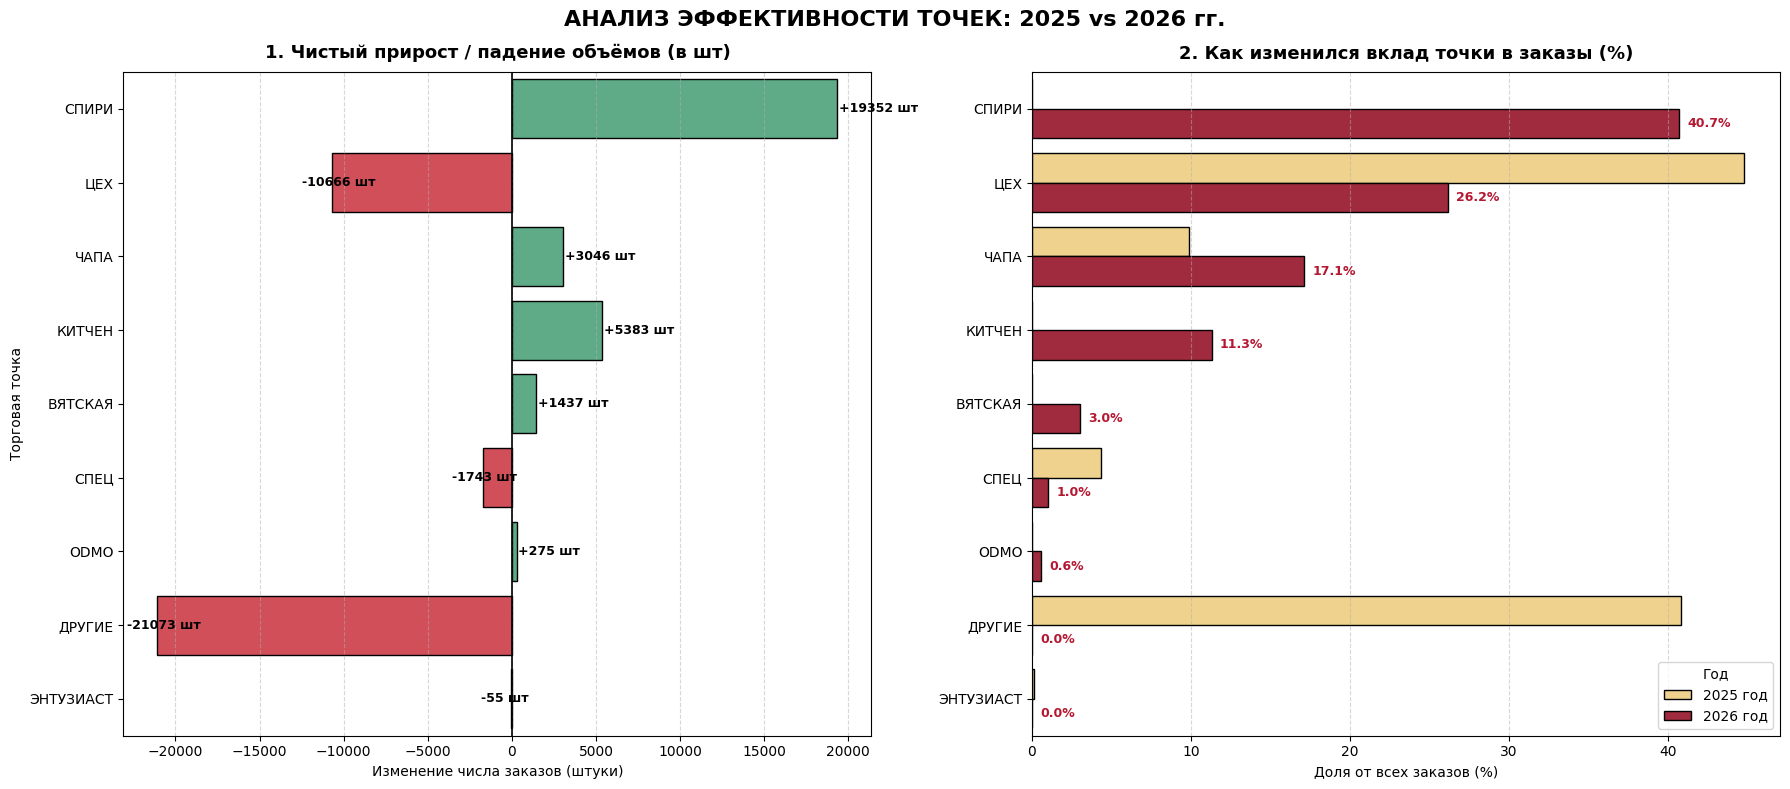

In [25]:
df_plot_points = points_compare.copy()
top_points_list = df_plot_points.sort_values('Sales_2026', ascending=False).head(8)['Point'].tolist()

# Схлопываем мелкие точки
df_plot_points.loc[~df_plot_points['Point'].isin(top_points_list), 'Point'] = 'ДРУГИЕ'
df_plot_points = df_plot_points.groupby('Point')[['Sales_2025', 'Sales_2026', 'Изменение_шт']].sum().reset_index()

# Пересчитываем доли для графика
df_plot_points['Доля_2025_%'] = (df_plot_points['Sales_2025'] / df_plot_points['Sales_2025'].sum()) * 100
df_plot_points['Доля_2026_%'] = (df_plot_points['Sales_2026'] / df_plot_points['Sales_2026'].sum()) * 100
df_plot_points = df_plot_points.sort_values('Sales_2026', ascending=False)

# 2. Переводим в длинный формат для Seaborn
df_melted_shares = df_plot_points.melt(
    id_vars=['Point'], 
    value_vars=['Доля_2025_%', 'Доля_2026_%'], 
    var_name='Год', 
    value_name='Доля_%'
)
df_melted_shares['Год'] = df_melted_shares['Год'].map({'Доля_2025_%': '2025 год', 'Доля_2026_%': '2026 год'})

# 3. Строим два графика рядом (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# График 1: Чистый прирост/падение в штуках
colors_gain = ['#52B788' if x >= 0 else '#E63946' for x in df_plot_points['Изменение_шт']]
sns.barplot(ax=axes[0], data=df_plot_points, x='Изменение_шт', y='Point', palette=colors_gain, edgecolor='black')
axes[0].axvline(0, color='black', linestyle='-', linewidth=1.2)
axes[0].set_title('1. Чистый прирост / падение объёмов (в шт)', fontsize=13, weight='bold', pad=10)
axes[0].set_xlabel('Изменение числа заказов (штуки)')
axes[0].set_ylabel('Торговая точка')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Добавляем подписи штук
for i, val in enumerate(df_plot_points['Изменение_шт']):
    axes[0].text(val + (100 if val >= 0 else -1800), i, f"{'+' if val > 0 else ''}{val:.0f} шт", va='center', weight='bold', fontsize=9)

# График 2: Изменение долей внутри сети
sns.barplot(ax=axes[1], data=df_melted_shares, x='Доля_%', y='Point', hue='Год', palette=['#FFD97D', '#B51731'], edgecolor='black')
axes[1].set_title('2. Как изменился вклад точки в заказы (%)', fontsize=13, weight='bold', pad=10)
axes[1].set_xlabel('Доля от всех заказов (%)')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

# Добавляем подписи процентов для 2026 года
for i, val in enumerate(df_plot_points['Доля_2026_%']):
    axes[1].text(val + 0.5, i + 0.2, f"{val:.1f}%", va='center', weight='bold', color='#B51731', fontsize=9)

plt.suptitle('АНАЛИЗ ЭФФЕКТИВНОСТИ ТОЧЕК: 2025 vs 2026 гг.', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

--- СРАВНЕНИЕ ГРУПП: КИТЧЕН+СПИРИ VS ОСТАЛЬНЫЕ ---
                        Group  2025 год  2026 год  Абс_изменение_шт  Динамика_%
ОСТАЛЬНАЯ СЕТЬ (без ЦЕХ/ЧАПА)   23360.0    2201.0          -21159.0  -90.577911


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_5976\3040322866.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_25_filtered['Group'] = df_25_filtered['Point'].apply(assign_group)
C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_5976\3040322866.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_26_filtered['Group'] = df_26_filtered['Point'].apply(assign_group)


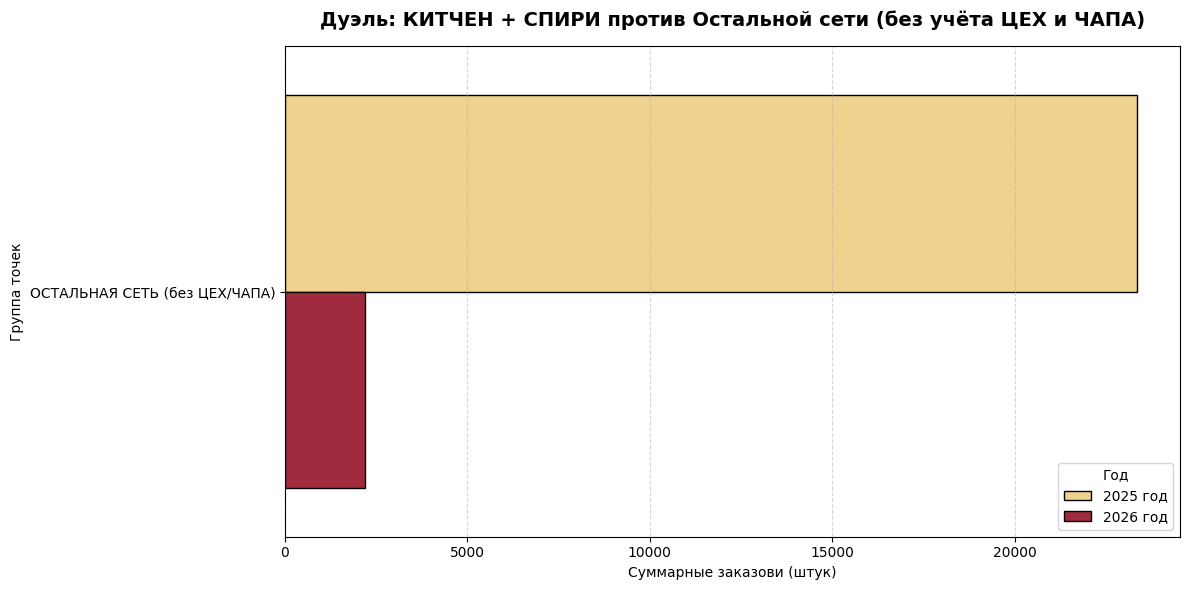

In [26]:
# 1. Готовим чистые копии данных с исправленными именами точек
df_25_clean = df_2025.copy()
df_26_clean = df_2026.copy()

for df in [df_25_clean, df_26_clean]:
    df['Point'] = df['Point'].astype(str).str.replace(r'(_2025|_26|_25|_2026)', '', case=False, regex=True).str.strip().str.upper()

# Исключаем ЦЕХ и ЧАПА из обоих датасетов полностью
df_25_filtered = df_25_clean[~df_25_clean['Point'].isin(['ЦЕХ', 'ЧАПА'])]
df_26_filtered = df_26_clean[~df_26_clean['Point'].isin(['ЦЕХ', 'ЧАПА'])]

# 2. Функция для разметки наших кастомных групп
def assign_group(point_name):
    if point_name in ['КИТЧЕН', 'СПИРИ']:
        return 'КИТЧЕН + СПИРИ'
    else:
        return 'ОСТАЛЬНАЯ СЕТЬ (без ЦЕХ/ЧАПА)'

df_25_filtered['Group'] = df_25_filtered['Point'].apply(assign_group)
df_26_filtered['Group'] = df_26_filtered['Point'].apply(assign_group)

# 3. Считаем суммарные заказови по группам для каждого года
group_25 = df_25_filtered.groupby('Group')['Count'].sum().reset_index(name='2025 год')
group_26 = df_26_filtered.groupby('Group')['Count'].sum().reset_index(name='2026 год')

# Склеиваем в итоговую таблицу сравнения
group_compare = pd.merge(group_25, group_26, on='Group')
group_compare['Абс_изменение_шт'] = group_compare['2026 год'] - group_compare['2025 год']
group_compare['Динамика_%'] = (group_compare['Абс_изменение_шт'] / group_compare['2025 год']) * 100

print("--- СРАВНЕНИЕ ГРУПП: КИТЧЕН+СПИРИ VS ОСТАЛЬНЫЕ ---")
print(group_compare.to_string(index=False))

# 4. ВИЗУАЛИЗАЦИЯ: Переводим в длинный формат для бар-плота
df_plot = group_compare.melt(id_vars=['Group'], value_vars=['2025 год', '2026 год'], var_name='Год', value_name='заказови')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='заказови', y='Group', hue='Год', palette=['#FFD97D', '#B51731'], edgecolor='black')
plt.title('Дуэль: КИТЧЕН + СПИРИ против Остальной сети (без учёта ЦЕХ и ЧАПА)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Суммарные заказови (штук)')
plt.ylabel('Группа точек')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_5976\3723004731.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


--- СРАВНЕНИЕ ОБЪЕМОВ заказов ---
     Группа для сравнения  Объём заказов (шт)
       Все B2B (2025 год)             23360.0
КИТЧЕН + СПИРИ (2026 год)             24735.0

Разница: +1375 шт (+5.9%)


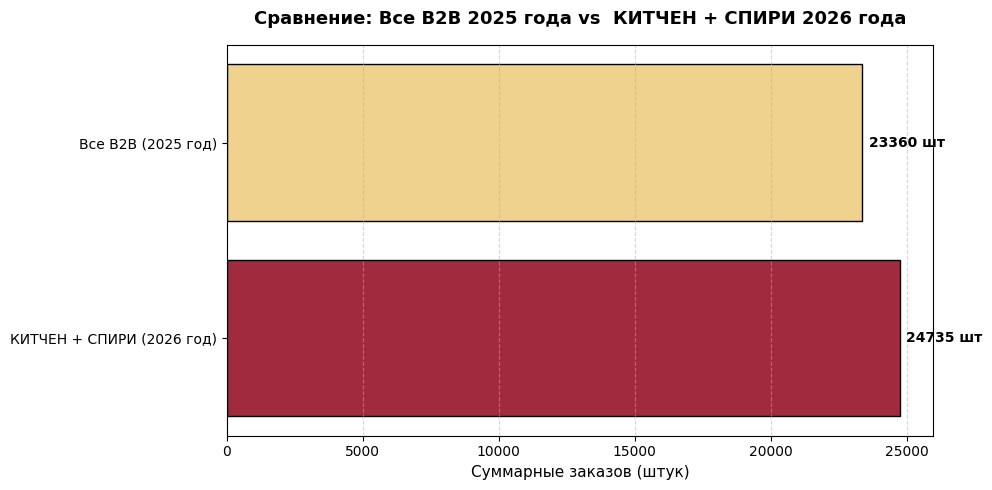

In [27]:

# 1. Очищаем имена точек от годов в обоих датасетах
df_25_clean = df_2025.copy()
df_26_clean = df_2026.copy()

df_25_clean['Point'] = df_25_clean['Point'].astype(str).str.replace(r'(_2025|_25|_2026|_26)', '', case=False, regex=True).str.strip().str.upper()
df_26_clean['Point'] = df_26_clean['Point'].astype(str).str.replace(r'(_2025|_25|_2026|_26)', '', case=False, regex=True).str.strip().str.upper()

# 2. РАСЧЕТ ДЛЯ 2025 ГОДА: Все точки, кроме ЦЕХ и ЧАПА
df_25_filtered = df_25_clean[~df_25_clean['Point'].isin(['ЦЕХ', 'ЧАПА'])]
total_old_network_2025 = df_25_filtered['Count'].sum()

# 3. РАСЧЕТ ДЛЯ 2026 ГОДА: Только КИТЧЕН и СПИРИ
df_26_filtered = df_26_clean[df_26_clean['Point'].isin(['КИТЧЕН', 'СПИРИ'])]
total_new_pair_2026 = df_26_filtered['Count'].sum()

# 4. Формируем таблицу сравнения
bench_data = pd.DataFrame({
    'Группа для сравнения': [
        'Все B2B (2025 год)', 
        'КИТЧЕН + СПИРИ (2026 год)'
    ],
    'Объём заказов (шт)': [total_old_network_2025, total_new_pair_2026]
})

# Вычисляем разницу
diff_pcs = total_new_pair_2026 - total_old_network_2025
diff_pct = (diff_pcs / total_old_network_2025) * 100 if total_old_network_2025 > 0 else 0

print("--- СРАВНЕНИЕ ОБЪЕМОВ заказов ---")
print(bench_data.to_string(index=False))
print(f"\nРазница: {diff_pcs:+.0f} шт ({diff_pct:+.1f}%)")

# 5. ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(10, 5))
sns.barplot(
    data=bench_data, 
    x='Объём заказов (шт)', 
    y='Группа для сравнения', 
    palette=['#FFD97D', '#B51731'], 
    edgecolor='black'
)

plt.title('Сравнение: Все B2B 2025 года vs  КИТЧЕН + СПИРИ 2026 года', fontsize=13, pad=15, weight='bold')
plt.xlabel('Суммарные заказов (штук)', fontsize=11)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Добавляем цифры прямо на бары
for i, val in enumerate(bench_data['Объём заказов (шт)']):
    plt.text(val + (bench_data['Объём заказов (шт)'].max() * 0.01), i, f"{val:.0f} шт", va='center', weight='bold')

plt.tight_layout()
plt.show()


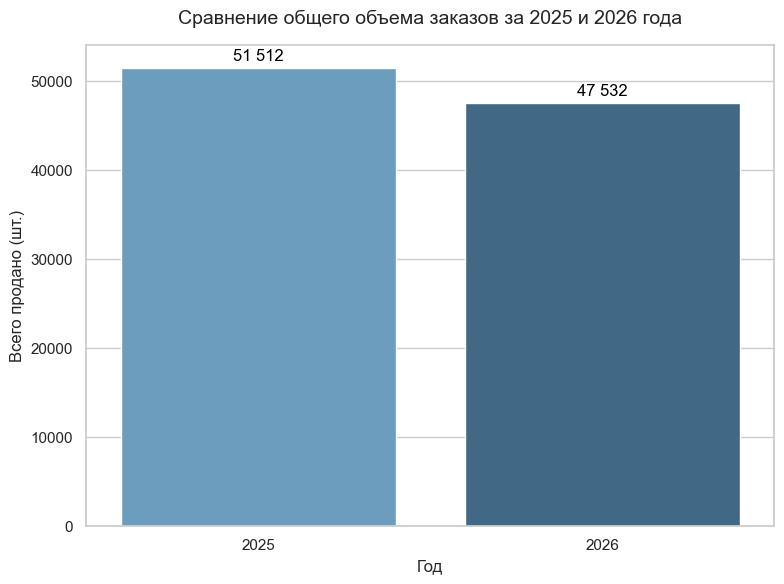

In [28]:
# 1. Считаем общие суммы заказов за каждый год
total_2025 = df_compare["Sales_2025"].sum()
total_2026 = df_compare["Sales_2026"].sum()

# 2. Создаем DataFrame для удобного построения графика через Seaborn
df_total = pd.DataFrame(
    {"Год": ["2025", "2026"], "заказови (шт.)": [total_2025, total_2026]}
)

# 3. Настраиваем стиль и строим график
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Строим столбцы
ax = sns.barplot(
    x="Год",
    y="заказови (шт.)",
    data=df_total,
    hue="Год",
    palette="Blues_d",
    legend=False,
)

# Добавляем числовые подписи над каждым столбцом
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}".replace(",", " "),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="baseline",
        fontsize=12,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )

# Настраиваем заголовки
plt.title("Сравнение общего объема заказов за 2025 и 2026 года", fontsize=14, pad=15)
plt.xlabel("Год", fontsize=12)
plt.ylabel("Всего продано (шт.)", fontsize=12)

# Оптимизируем поля и показываем график
plt.tight_layout()
plt.show()

In [29]:
df_total

,Год,заказови (шт.)
0,2025,51512.0
1,2026,47532.0


In [30]:
df_compare["Sales_2025"].sum()

np.float64(51512.0)

In [31]:
df_compare

,Category,Name,Sales_2025,Sales_2026,Delta_Pcs,Delta_%,Total_Both_Years,Product_Type
0,Булки,Бабка карамелизированный шоколад и кокос,0.0,0.0,0.0,100.000000,0.0,Старый ассортимент (LFL)
1,Булки,Бейгл 100,3985.0,4009.0,24.0,0.602258,7994.0,Старый ассортимент (LFL)
2,Булки,Бриошь ревень-клубника,0.0,791.0,791.0,100.000000,791.0,Новинки 2026
3,Булки,Бриошь с ванильным кремом в ягодной глазури,928.0,0.0,-928.0,-100.000000,928.0,Удалено из меню
4,Булки,Булка кофе-апельсин,0.0,0.0,0.0,100.000000,0.0,Старый ассортимент (LFL)
...,...,...,...,...,...,...,...,...
109,Хлеб,"Тартин 1,5",1742.0,1200.0,-542.0,-31.113662,2942.0,Старый ассортимент (LFL)
110,Хлеб,Тартин гречка,1340.0,969.0,-371.0,-27.686567,2309.0,Старый ассортимент (LFL)
111,Хлеб,Фокачча 400х600,1481.0,282.0,-1199.0,-80.958812,1763.0,Старый ассортимент (LFL)
112,Хлеб,Фокачча GN 1/3,135.0,1.0,-134.0,-99.259259,136.0,Старый ассортимент (LFL)
